In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [55]:
dataset=pd.read_csv("../Datasets/Dataset_regression.csv")
dataset

,area_sqft,bedrooms,bathrooms,house_age,distance_city_km,income_k,rooms,crime_rate,garage_spaces,school_rating,price
0,3774.0,1.0,4.4,44.0,12.41,24.58,9.0,3.93,2.0,4.9,881889.277081
1,4107.0,5.0,NaN,25.0,34.27,113.32,3.0,3.57,2.0,6.2,752923.379433
2,1460.0,4.0,1.6,38.0,30.12,21.81,11.0,11.17,1.0,6.3,237217.344515
3,1894.0,1.0,3.8,27.0,24.84,145.98,6.0,5.14,2.0,7.9,453706.228068
4,1730.0,5.0,3.3,4.0,25.72,69.03,5.0,7.84,3.0,9.6,652759.993302
...,...,...,...,...,...,...,...,...,...,...,...
995,2084.0,1.0,2.4,40.0,15.27,121.56,NaN,13.76,2.0,8.8,582541.947060
996,2233.0,5.0,4.2,28.0,2.72,49.83,10.0,2.92,2.0,6.9,925061.912148
997,2752.0,3.0,3.5,8.0,2.34,139.90,6.0,2.26,0.0,4.3,897998.490678
998,3770.0,2.0,3.1,12.0,20.51,107.31,8.0,1.74,0.0,6.3,824286.488731


In [56]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         941 non-null    float64
 1   bedrooms          951 non-null    float64
 2   bathrooms         953 non-null    float64
 3   house_age         950 non-null    float64
 4   distance_city_km  945 non-null    float64
 5   income_k          948 non-null    float64
 6   rooms             943 non-null    float64
 7   crime_rate        952 non-null    float64
 8   garage_spaces     960 non-null    float64
 9   school_rating     951 non-null    float64
 10  price             1000 non-null   float64
dtypes: float64(11)
memory usage: 86.1 KB


In [57]:
X=dataset.iloc[:,4:5].values
y=dataset.iloc[:,-1].values


In [58]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(missing_values=np.nan,strategy="mean")
si.fit(X)
X=si.fit_transform(X)


In [59]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
X_poly=poly.fit_transform(X)

In [60]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

lr.fit(X_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-9651.46, -61.05, -2.5 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.026e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[367093.26, 1868.89, 26.82, 0. ]"


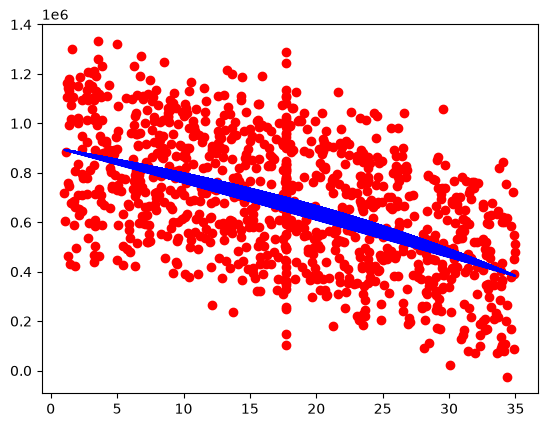

In [69]:
plt.scatter(X,y,color='red')
plt.plot(X,lr.predict(X_poly),color='blue')
plt.show()

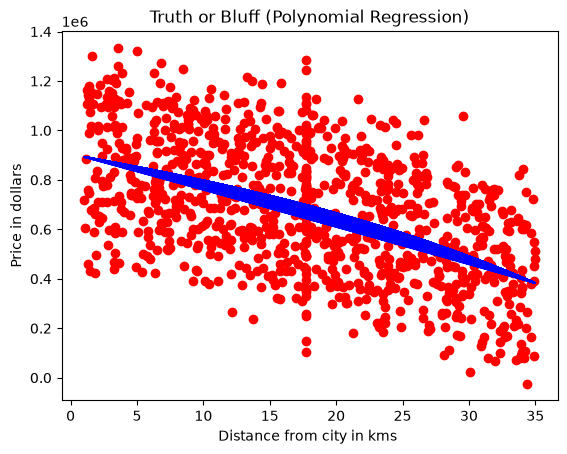

In [68]:
plt.scatter(X,y,color='red')
plt.plot(X,lr.predict(X_poly),color="blue")
plt.title("Truth or Bluff (Polynomial Regression)")
plt.xlabel("Distance from city in kms ")
plt.ylabel("Price in dollars")
plt.show()